In [24]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import plotly.io as pio
import numdifftools as nd
pio.renderers.default = 'iframe'

import time
np.random.seed(0)

import multiprocess as mp

from js import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
df = pd.read_csv('../data/nsduh/nsduh23tab.txt', sep='\t')
df.head()

/var/folders/fg/n7d57ft153bf46npr6w6jjxr0000gn/T/ipykernel_45965/1475866788.py:1: DtypeWarning:

Columns (2635) have mixed types. Specify dtype option on import or set low_memory=False.



,QUESTID2,FILEDATE,ANALWT2_C,VESTR_C,VEREP,PDEN10,COUTYP4,MAIIN102,AIIND102,AGE3,...,COSUTELE2,COSUAPTDL2,COSURXDL2,COSUSVHLT2,COHCTELE2,COHCAPTDL2,COHCRXDL2,COHCSVHLT2,LANGVER,GQTYPE2
0,10000053,10/21/2024,3276.469874,40031,2,2,2,2,2,10,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1,NaN
1,10000679,10/21/2024,15630.082955,40021,2,2,3,2,2,9,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1,NaN
2,10001208,10/21/2024,4018.172390,40043,1,2,2,2,2,9,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1,NaN
3,10001260,10/21/2024,10711.709540,40030,2,2,2,2,2,1,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1,NaN
4,10001588,10/21/2024,8195.104779,40023,2,2,2,2,2,10,...,3.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,1,NaN


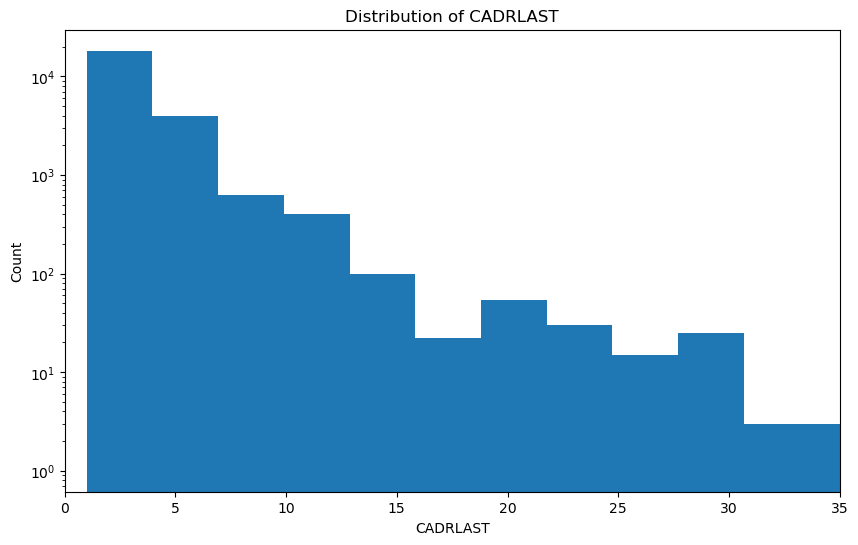

In [12]:
drinks = df['CADRLAST'].dropna()
drinks = drinks[(drinks >= 1) & (drinks <= 90)]
plt.figure(figsize=(10,6))
plt.hist(drinks, bins=30)
plt.xlim(0, 35)
plt.yscale('log')
plt.title('Distribution of CADRLAST')
plt.xlabel('CADRLAST')
plt.ylabel('Count')
plt.show()


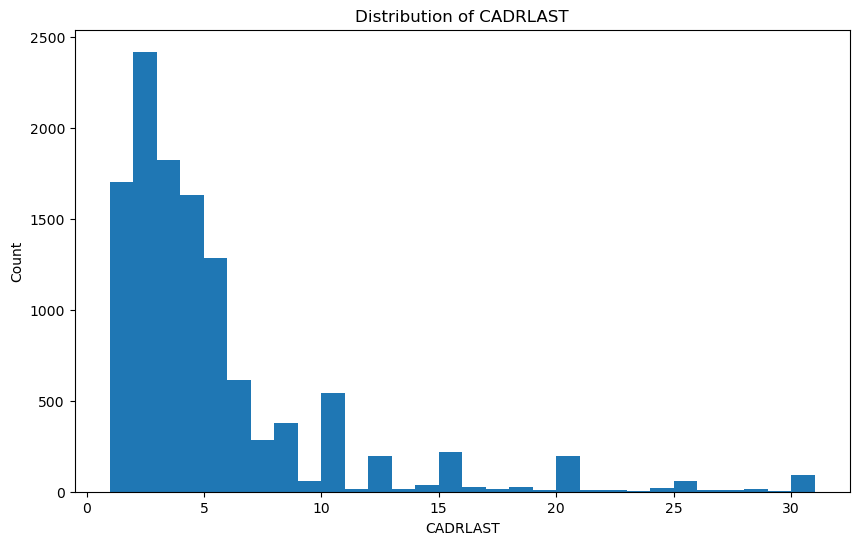

In [14]:
monthly = df['ALDAYPMO'].dropna()
monthly = monthly[(monthly >= 1) & (monthly <= 31)]
plt.figure(figsize=(10,6))
plt.hist(monthly, bins=30)
# # plt.xlim(0, 35)
# plt.yscale('log')
plt.title('Distribution of CADRLAST')
plt.xlabel('CADRLAST')
plt.ylabel('Count')
plt.show()


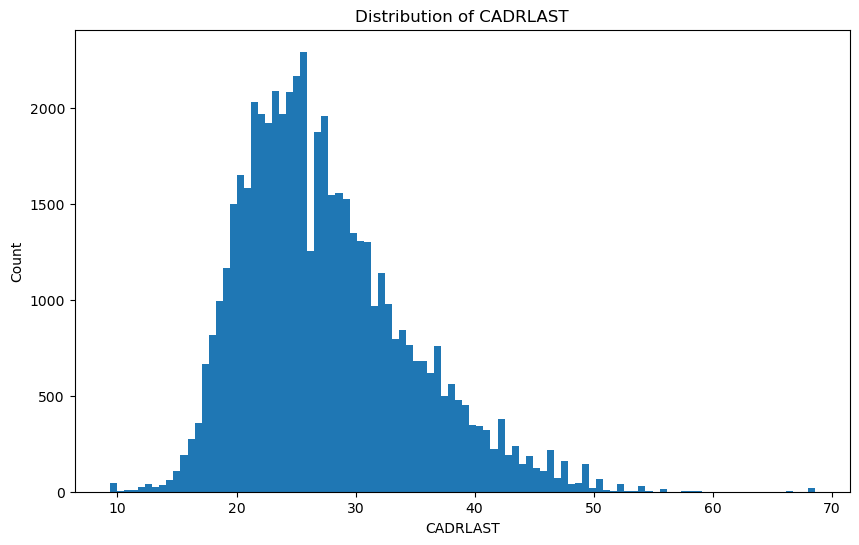

In [131]:
bmi = df['BMI2'].dropna()
# drinks2 = 
plt.figure(figsize=(10,6))
plt.hist(bmi, bins=100)
# # plt.xlim(0, 35)
# plt.yscale('log')
plt.title('Distribution of CADRLAST')
plt.xlabel('CADRLAST')
plt.ylabel('Count')
plt.show()


In [42]:
S_bnds = [9.3, 68.6]
S = stats.uniform(S_bnds[0], S_bnds[1])
Ys_plot = np.linspace(S_bnds[0], S_bnds[1], 100)

In [22]:
n = len(bmi)
Ys = np.array(bmi).reshape((n,1))
Ss = S.rvs(size=r*n).reshape((n,r))
Zs = np.sort(np.hstack((Ys, Ss)), axis=1)

In [39]:
k = np.vectorize(lambda x:np.exp(-(x**2)/(2*.25))/(np.sqrt(2*np.pi*.25)))
mabg = lambda a,b,g: quad(lambda t: (t**a)*(g(t)**b), -np.inf, np.inf)[0]
h_kde = 1
k_kde = stats.norm.pdf
kde = lambda y: (1/(n*h_kde))*np.sum(k_kde((y-bmi)/h_kde))
coeffJS = mabg(0,2,k)/((mabg(2,1,k)**2)*mabg(0, 2, deriv(kde, 2)))

In [40]:
def hstarJS(n, r):
    return ((coeffJS*(r+1))**(1/5))/(n**(1/5))

In [57]:
res = []
for r in range(1, 6):
    h = hstarJS(n, r)
    jspdfe = jspdfest(Zs, S, k, S_bnds, h, r, n)(Ys_plot)
    res.append([r, jspdfe, h])

In [132]:
import pickle
resR = pickle.load(open('bmijspdf.pkl', 'rb'))

<>:6: SyntaxWarning:

invalid escape sequence '\,'

<>:6: SyntaxWarning:

invalid escape sequence '\,'

/var/folders/fg/n7d57ft153bf46npr6w6jjxr0000gn/T/ipykernel_45965/2566750004.py:6: SyntaxWarning:

invalid escape sequence '\,'



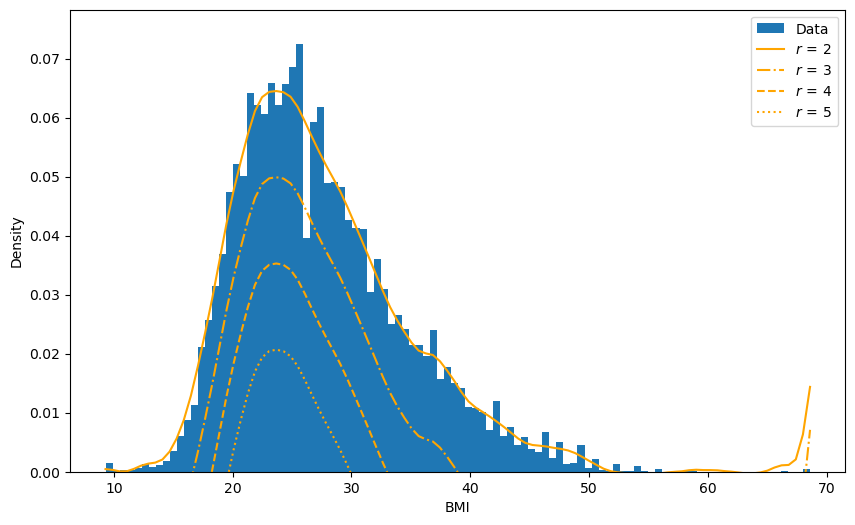

In [133]:
plt.figure(figsize=(10,6))
plt.hist(Ys, bins=100, density=True, label='Data')

for i, r_res in enumerate(resR[1:]):
    r, jspdfe, h = r_res
    plt.plot(Ys_plot, jspdfe, label=f'$r\,=\,{r}$', 
             linestyle=['-', '-.', '--', ':'][i], color='orange')

plt.xlabel('BMI')
plt.ylabel('Density')
plt.ylim(bottom=0)
# plt.title('Joint Scrambling Kernel Density Estimate for Varying ')
plt.legend()
# plt.grid(True)
plt.show()


In [75]:
r = 2 
hs = [0.1, 0.5, 1.0, 2.0]  # Range of bandwidths to try
hs.append(hstarJS(n, r))

res = []
for h in hs:
    jspdfe = jspdfest(Zs, S, k, S_bnds, h, r, n)(Ys_plot)
    res.append([h, jspdfe])


In [135]:
import pickle
resH = pickle.load(open('bmijspdfH.pkl', 'rb'))


<>:8: SyntaxWarning:

invalid escape sequence '\,'

<>:23: SyntaxWarning:

invalid escape sequence '\,'

<>:25: SyntaxWarning:

invalid escape sequence '\;'

<>:8: SyntaxWarning:

invalid escape sequence '\,'

<>:23: SyntaxWarning:

invalid escape sequence '\,'

<>:25: SyntaxWarning:

invalid escape sequence '\;'

/var/folders/fg/n7d57ft153bf46npr6w6jjxr0000gn/T/ipykernel_45965/3981007592.py:8: SyntaxWarning:

invalid escape sequence '\,'

/var/folders/fg/n7d57ft153bf46npr6w6jjxr0000gn/T/ipykernel_45965/3981007592.py:23: SyntaxWarning:

invalid escape sequence '\,'

/var/folders/fg/n7d57ft153bf46npr6w6jjxr0000gn/T/ipykernel_45965/3981007592.py:25: SyntaxWarning:

invalid escape sequence '\;'



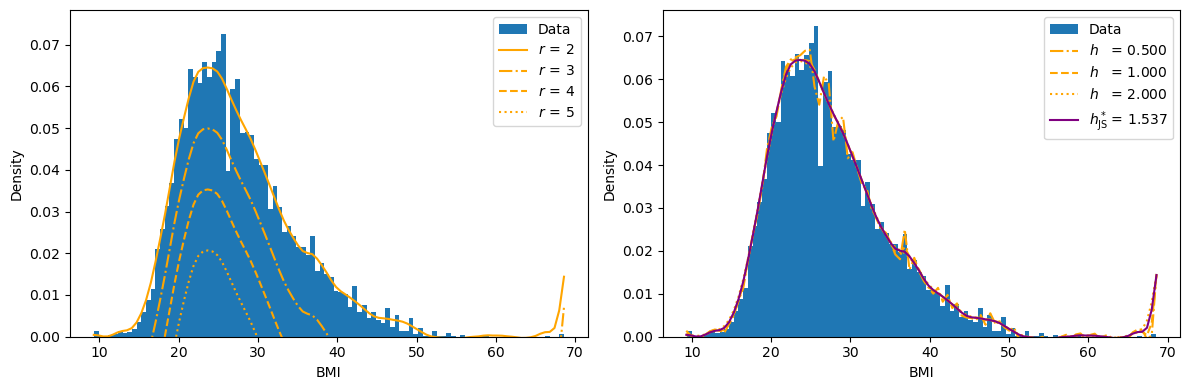

In [140]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

# First subplot
ax1.hist(Ys, bins=100, density=True, label='Data')

for i, r_res in enumerate(resR[1:]):
    r, jspdfe, h = r_res
    ax1.plot(Ys_plot, jspdfe, label=f'$r\,=\,{r}$', 
             linestyle=['-', '-.', '--', ':'][i], color='orange')

ax1.set_xlabel('BMI')
ax1.set_ylabel('Density')
ax1.set_ylim(bottom=0)
# ax1.set_title('Joint Scrambling Kernel Density Estimate for Varying ')
ax1.legend()

# Second subplot
ax2.hist(Ys, bins=100, density=True, label='Data', color="tab:blue")

# Plot for different bandwidths
for i, (h, jspdfe) in enumerate(resH[1:]):
    if h == hstarJS(n, 2):
        ax2.plot(Ys_plot, jspdfe, label='$h_{\\rm JS}^*=\,'+f'{h:.3f}$', color='purple')
    else:
        ax2.plot(Ys_plot, jspdfe, label=f'$h\;\;\,=\,{h:.3f}$', linestyle=['-.', '--', ':'][i], color="orange")

ax2.set_xlabel('BMI')
ax2.set_ylabel('Density')
ax2.set_ylim(bottom=0)
# ax2.set_title('Joint Scrambling KDE for Different Bandwidths')
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\


In [ ]:
ind = 2
for j in range(3):
    for i in [0,2,1]:
        if i == 0: print("Joint Scrambling", end=" ")
        elif i == 2: print("\\citep{shou2023kernel}", end=" ")
        else: print("\\citep{ahmad2002kernel}", end=" ")
            
        t, h, ib, var, mise = np.array(metrics(res[j*B:(j+1)*B]))[:,i]
        print(("& $10^{:0.0f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$ & ${:0.3f}$").format(j+2, h, t, ib*100, var*100, mise*100), end="\\\\\n")
    if j < 2: print("\\"*4)
# metrics(res[B:2*B])

Joint Scrambling & $10^2$ & $1.051$ & $0.106$ & $12.228$ & $0.599$ & $0.930$\\
\citep{shou2023kernel} & $10^2$ & $0.987$ & $0.238$ & $28.908$ & $0.152$ & $2.040$\\
\citep{ahmad2002kernel} & $10^2$ & $0.366$ & $0.024$ & $25.031$ & $9.553$ & $14.286$\\
\\\\
Joint Scrambling & $10^3$ & $0.663$ & $0.439$ & $5.476$ & $0.165$ & $0.232$\\
\citep{shou2023kernel} & $10^3$ & $0.623$ & $3.049$ & $26.035$ & $0.017$ & $1.549$\\
\citep{ahmad2002kernel} & $10^3$ & $0.263$ & $0.221$ & $22.815$ & $1.336$ & $6.190$\\
\\\\
Joint Scrambling & $10^4$ & $0.418$ & $3.468$ & $1.754$ & $0.026$ & $0.034$\\
\citep{shou2023kernel} & $10^4$ & $0.393$ & $64.822$ & $24.841$ & $0.002$ & $1.400$\\
\citep{ahmad2002kernel} & $10^4$ & $0.190$ & $2.226$ & $22.820$ & $0.176$ & $5.259$\\
